In [61]:
import kagglehub

#download dataset
path = kagglehub.dataset_download("gauravtopre/bank-customer-churn-dataset")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\hp\.cache\kagglehub\datasets\gauravtopre\bank-customer-churn-dataset\versions\1


In [62]:
import pandas as pd
 #loading dataset
data = pd.read_csv(path + "\Bank-Customer-Churn-Prediction.csv")
data.head(3)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


In [63]:
# save the unprocessed data to data/raw folder
data.to_csv("../data/raw/Bank-Customer-Churn-Prediction.csv", index=False)

print("Raw data saved successfully!")
print(f"Dataset shape: {data.shape}")

Raw data saved successfully!
Dataset shape: (10000, 12)


In [64]:
data.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [65]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Setting style
sns.set_style('whitegrid')
%matplotlib inline

In [67]:
#deleting 'CustomerId' column
data = data.drop(columns=['customer_id'])

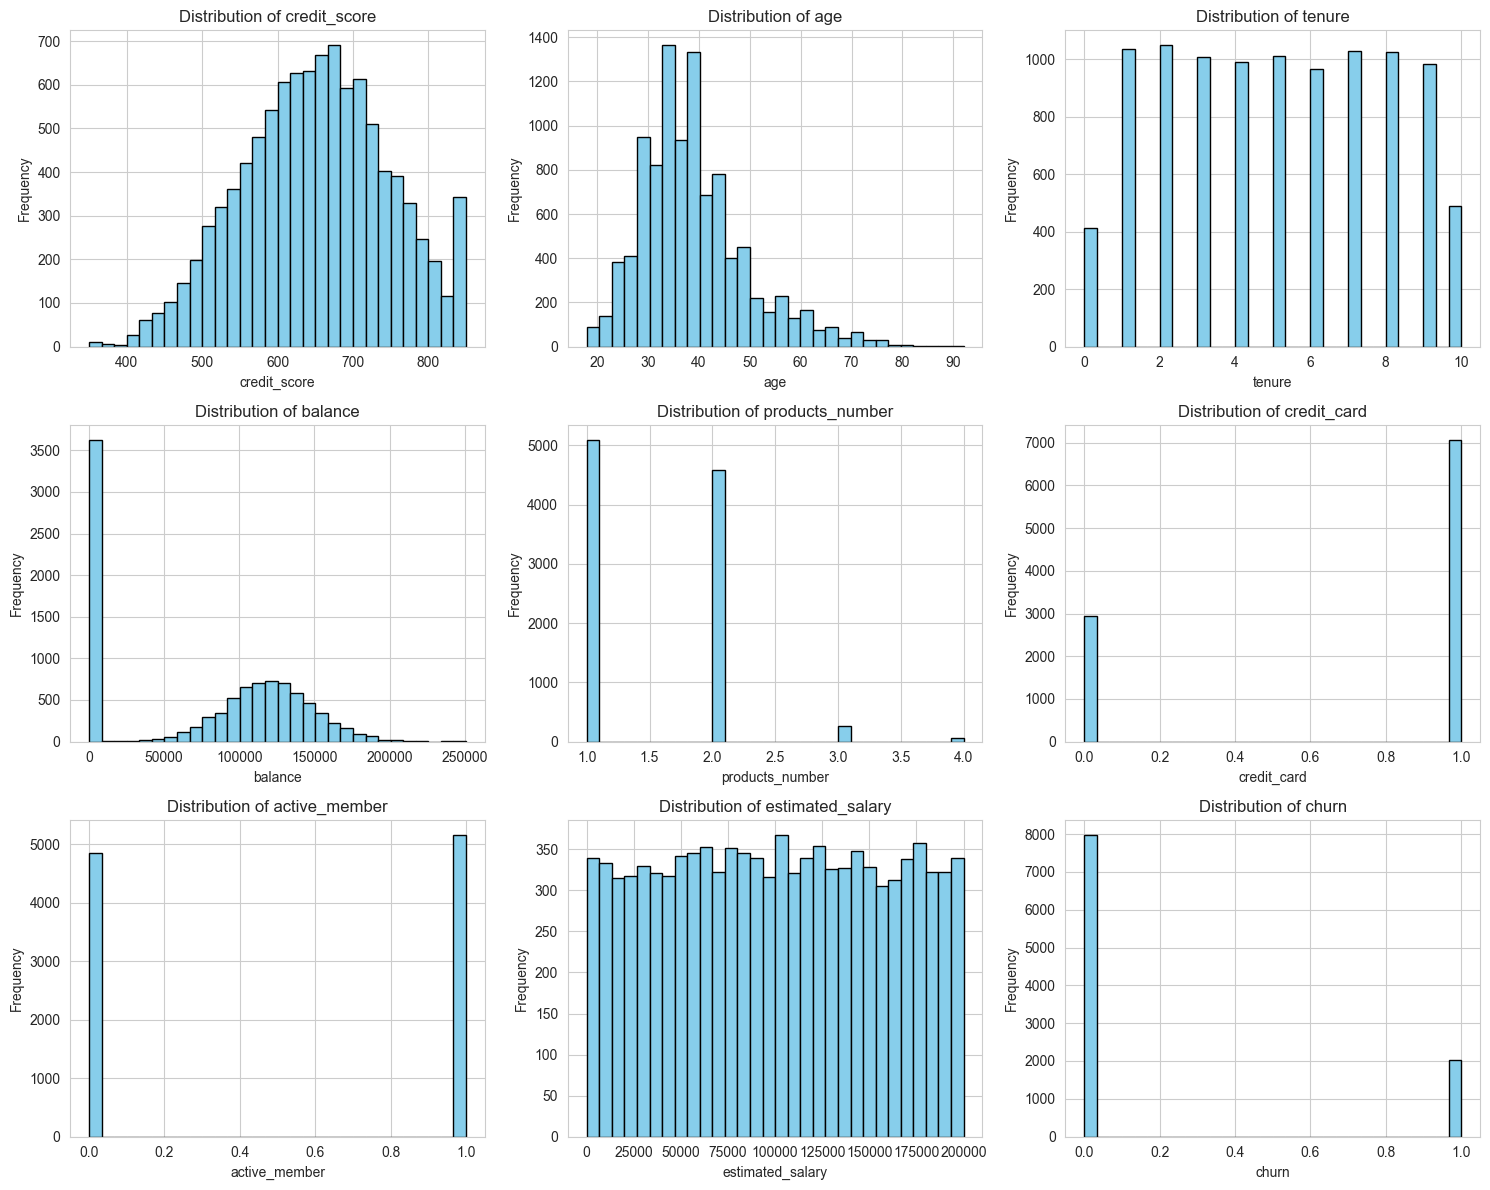

In [68]:
# Getting all numerical columns
numerical_cols = data.select_dtypes(include=[np.number]).columns.tolist()

# Creating histograms
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    if i < len(axes):
        axes[i].hist(data[col], bins=30, color='skyblue', edgecolor='black')
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

# Remove empty subplots if any
for i in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

Percentages:
country
France     50.14
Germany    25.09
Spain      24.77
Name: proportion, dtype: float64
Percentages:
gender
Male      54.57
Female    45.43
Name: proportion, dtype: float64


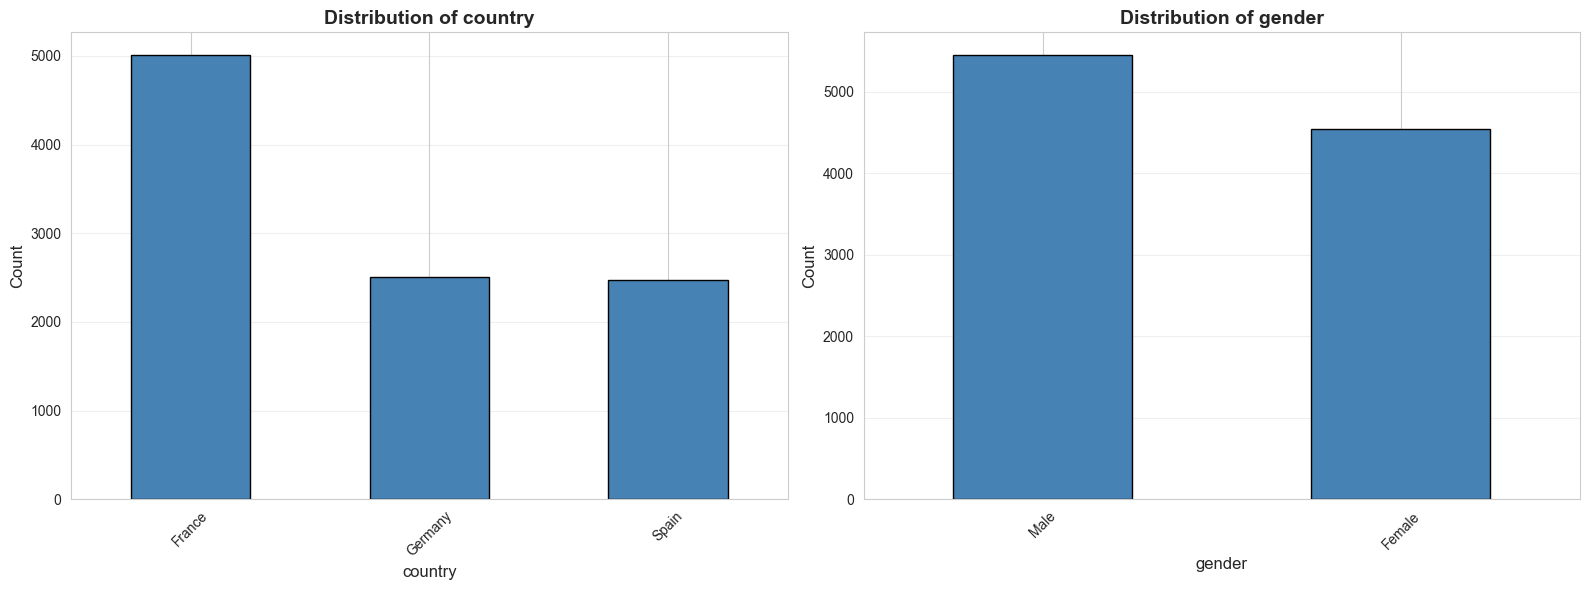

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get categorical columns
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()

# Create subplots in one row (horizontal layout)
fig, axes = plt.subplots(1, len(categorical_cols), figsize=(16, 6))

# If only one categorical column, make axes a list
if len(categorical_cols) == 1:
    axes = [axes]

# Visualize each categorical variable
for i, col in enumerate(categorical_cols):
    data[col].value_counts().plot(kind='bar', 
                                 color='steelblue', 
                                 edgecolor='black',
                                 ax=axes[i])
    axes[i].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', alpha=0.3)
    
    print(f"Percentages:")
    print(data[col].value_counts(normalize=True) * 100)

plt.tight_layout()
plt.show()


In [70]:
# Selecting only numerical columns for correlation
numerical_cols = data.select_dtypes(include=[np.number]).columns
data_numerical = data[numerical_cols]

# Calculating correlation matrix
correlation_matrix = data_numerical.corr()

print(correlation_matrix)

                  credit_score       age    tenure   balance  products_number  \
credit_score          1.000000 -0.003965  0.000842  0.006268         0.012238   
age                  -0.003965  1.000000 -0.009997  0.028308        -0.030680   
tenure                0.000842 -0.009997  1.000000 -0.012254         0.013444   
balance               0.006268  0.028308 -0.012254  1.000000        -0.304180   
products_number       0.012238 -0.030680  0.013444 -0.304180         1.000000   
credit_card          -0.005458 -0.011721  0.022583 -0.014858         0.003183   
active_member         0.025651  0.085472 -0.028362 -0.010084         0.009612   
estimated_salary     -0.001384 -0.007201  0.007784  0.012797         0.014204   
churn                -0.027094  0.285323 -0.014001  0.118533        -0.047820   

                  credit_card  active_member  estimated_salary     churn  
credit_score        -0.005458       0.025651         -0.001384 -0.027094  
age                 -0.011721       0.0

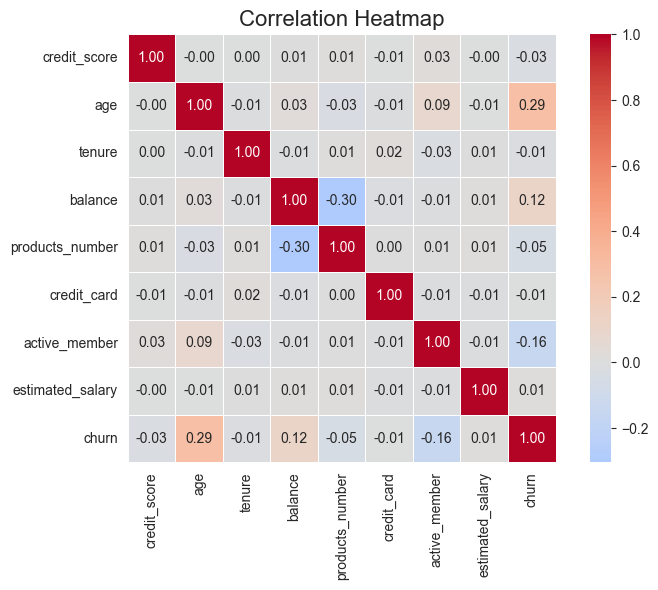

In [71]:
# Create correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, 
            annot=True,           # Show correlation values
            cmap='coolwarm',      # Color scheme (red=positive, blue=negative)
            center=0,             # Center colormap at 0
            fmt='.2f',            
            square=True,          
            linewidths=0.5)       

plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

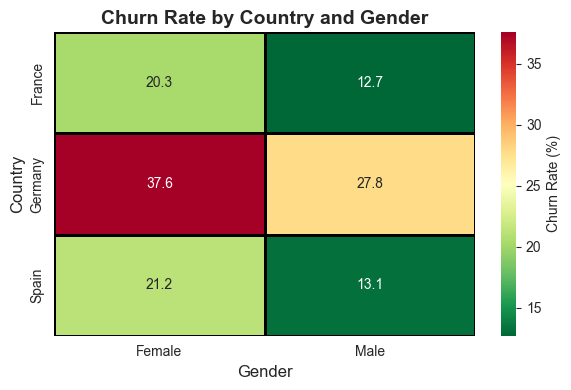


Churn Rate by Country and Gender:
gender      Female       Male
country                      
France   20.344980  12.713404
Germany  37.552389  27.811550
Spain    21.212121  13.112392


In [72]:
# If you have multiple categorical variables (gender and country)
if 'gender' in data.columns and 'country' in data.columns:
    # Create a pivot table
    pivot = data.pivot_table(values='churn', 
                           index='country', 
                           columns='gender', 
                           aggfunc='mean') * 100
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', 
                cbar_kws={'label': 'Churn Rate (%)'}, 
                linewidths=1, linecolor='black')
    plt.title('Churn Rate by Country and Gender', fontsize=14, fontweight='bold')
    plt.xlabel('Gender', fontsize=12)
    plt.ylabel('Country', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    print("\nChurn Rate by Country and Gender:")
    print(pivot)

In [73]:
# Count of churned vs non-churned customers
churn_counts = data['churn'].value_counts()
print("Churn Counts:")
print(churn_counts)

# Percentage distribution
churn_percentage = data['churn'].value_counts(normalize=True) * 100
print("\nChurn Percentage:")
print(churn_percentage)

Churn Counts:
churn
0    7963
1    2037
Name: count, dtype: int64

Churn Percentage:
churn
0    79.63
1    20.37
Name: proportion, dtype: float64


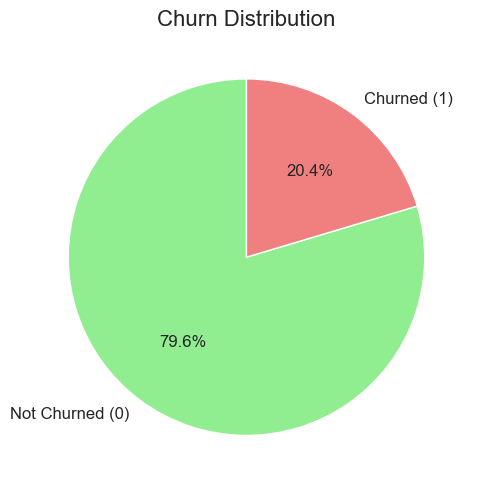

In [74]:
# Pie chart
plt.figure(figsize=(8, 5))
colors = ['lightgreen', 'lightcoral']
labels = ['Not Churned (0)', 'Churned (1)']

plt.pie(churn_counts, labels=labels, colors=colors, autopct='%1.1f%%', 
        startangle=90, textprops={'fontsize': 12})
plt.title('Churn Distribution', fontsize=16)
plt.tight_layout()
plt.show()

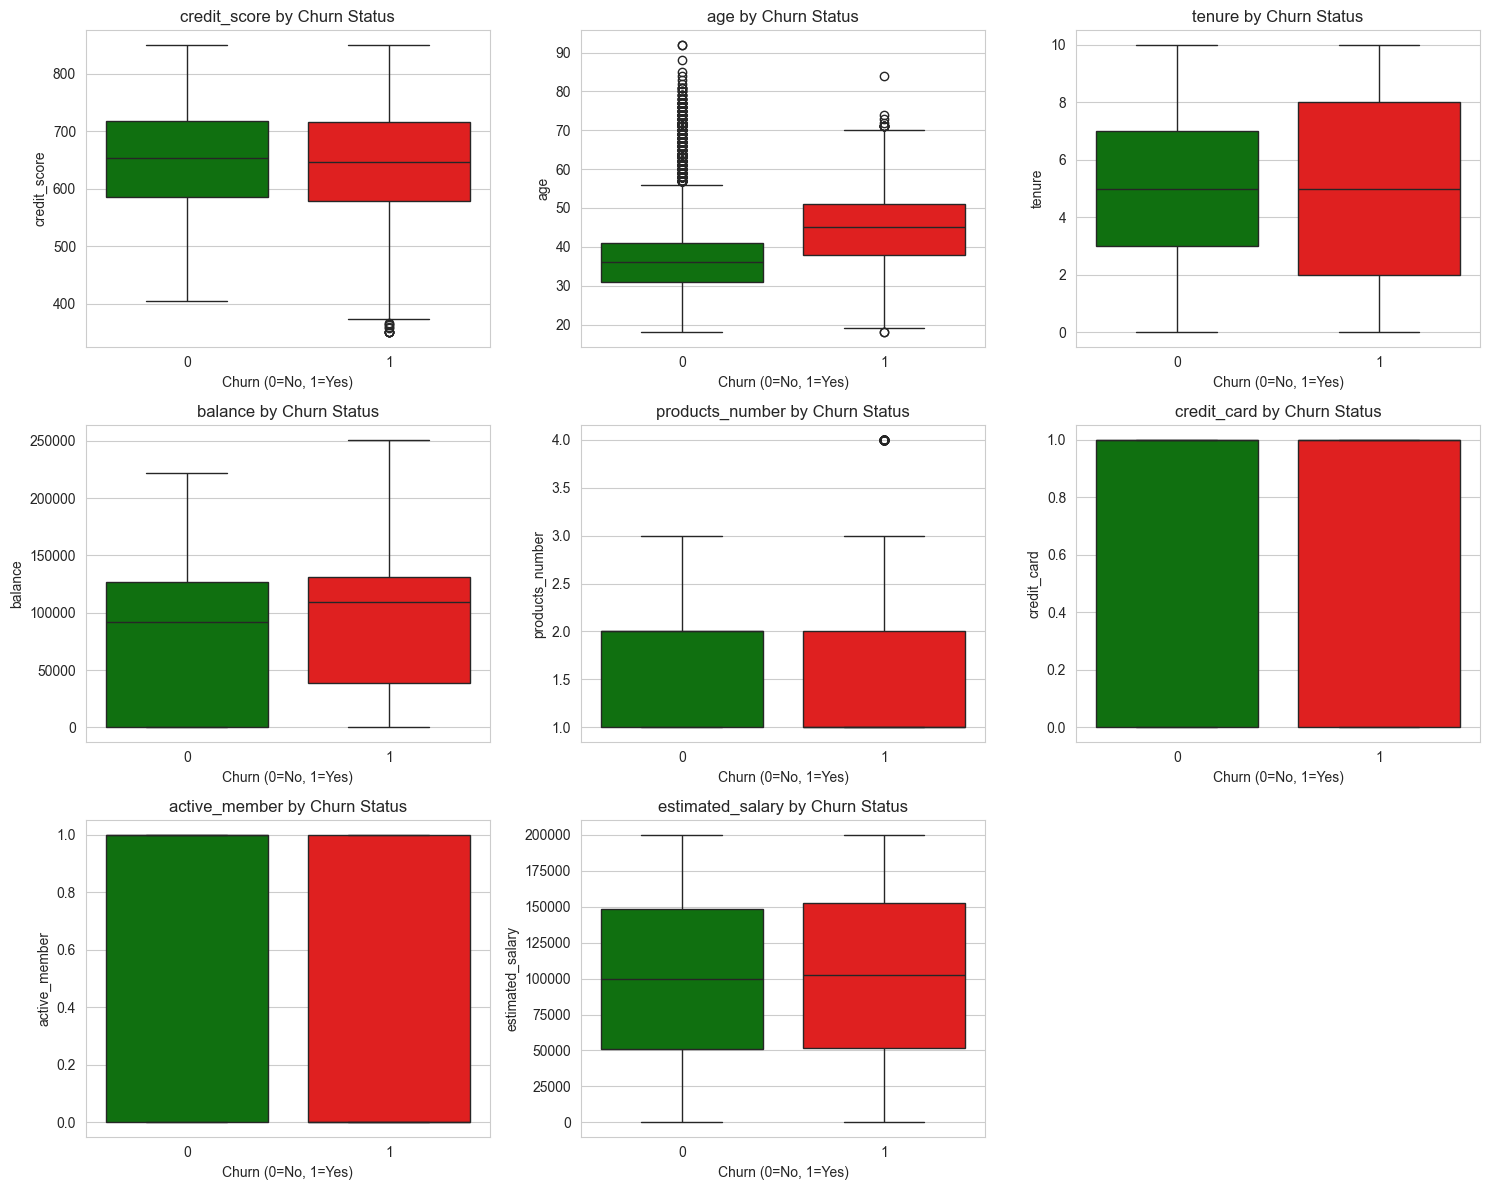

In [75]:
import warnings 
warnings.filterwarnings('ignore')

# Get numerical columns (excluding churn itself)
numerical_cols = data.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols.remove('churn')  # Remove target from the list

# Create boxplots
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    if i < len(axes):
        sns.boxplot(data=data, x='churn', y=col, ax=axes[i], palette=['green', 'red'])
        axes[i].set_title(f'{col} by Churn Status')
        axes[i].set_xlabel('Churn (0=No, 1=Yes)')

# Remove empty subplots
for i in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

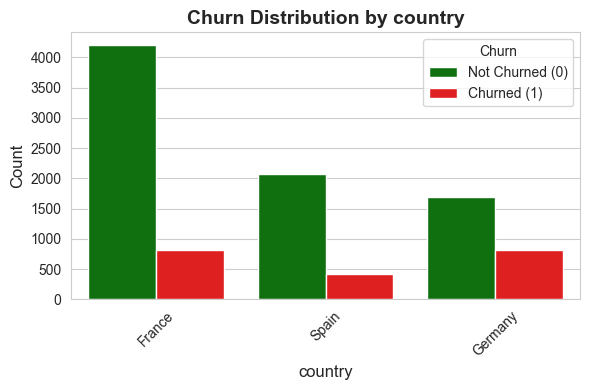


Churn counts by country:
churn       0    1
country           
France   4204  810
Germany  1695  814
Spain    2064  413


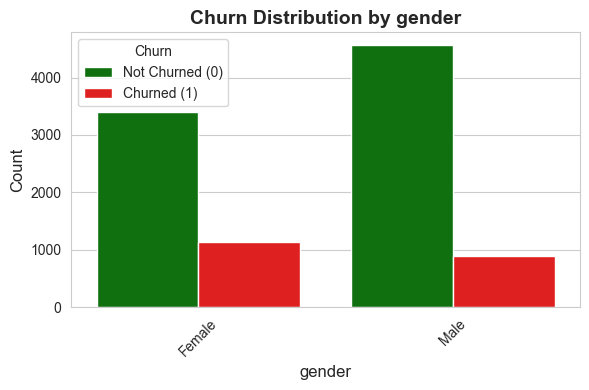


Churn counts by gender:
churn      0     1
gender            
Female  3404  1139
Male    4559   898


In [76]:
# Visualize relationship between categorical variables and churn
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    
    # Count plot with hue for churn
    sns.countplot(data=data, x=col, hue='churn', palette=['green', 'red'])
    plt.title(f'Churn Distribution by {col}', fontsize=14, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.legend(title='Churn', labels=['Not Churned (0)', 'Churned (1)'])
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Print churn counts per category
    print(f"\nChurn counts by {col}:")
    print(pd.crosstab(data[col], data['churn']))

In [84]:
def detect_outliers_iqr(data, column):
    #Détecte les outliers en utilisant la méthode IQR (Interquartile Range)
    Q1 = data[column].quantile(0.25)  # Premier quartile (25%)
    Q3 = data[column].quantile(0.75)  # Troisième quartile (75%)
    IQR = Q3 - Q1                      # Interquartile Range
    
    # Limites pour les outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identifier les outliers
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    return outliers, lower_bound, upper_bound, Q1, Q3, IQR

for col in numerical_cols:
    outliers, lower, upper, Q1, Q3, IQR = detect_outliers_iqr(data, col)
    
    print(f"\n{col}:")
    print(f"  Q1 (25%): {Q1:.2f}")
    print(f"  Q3 (75%): {Q3:.2f}")
    print(f"  IQR: {IQR:.2f}")
    print(f"  Limite inférieure: {lower:.2f}")
    print(f"  Limite supérieure: {upper:.2f}")
    print(f"  Nombre d'outliers: {len(outliers)} ({len(outliers)/len(data)*100:.2f}%)")
    
    if len(outliers) > 0:
        print(f"Valeurs extrêmes détectées!")
        print(f"Min outlier: {outliers[col].min():.2f}")
        print(f"Max outlier: {outliers[col].max():.2f}")


credit_score:
  Q1 (25%): 584.00
  Q3 (75%): 718.00
  IQR: 134.00
  Limite inférieure: 383.00
  Limite supérieure: 919.00
  Nombre d'outliers: 15 (0.15%)
Valeurs extrêmes détectées!
Min outlier: 350.00
Max outlier: 382.00

age:
  Q1 (25%): 32.00
  Q3 (75%): 44.00
  IQR: 12.00
  Limite inférieure: 14.00
  Limite supérieure: 62.00
  Nombre d'outliers: 359 (3.59%)
Valeurs extrêmes détectées!
Min outlier: 63.00
Max outlier: 92.00

tenure:
  Q1 (25%): 3.00
  Q3 (75%): 7.00
  IQR: 4.00
  Limite inférieure: -3.00
  Limite supérieure: 13.00
  Nombre d'outliers: 0 (0.00%)

balance:
  Q1 (25%): 0.00
  Q3 (75%): 127644.24
  IQR: 127644.24
  Limite inférieure: -191466.36
  Limite supérieure: 319110.60
  Nombre d'outliers: 0 (0.00%)

products_number:
  Q1 (25%): 1.00
  Q3 (75%): 2.00
  IQR: 1.00
  Limite inférieure: -0.50
  Limite supérieure: 3.50
  Nombre d'outliers: 60 (0.60%)
Valeurs extrêmes détectées!
Min outlier: 4.00
Max outlier: 4.00

credit_card:
  Q1 (25%): 0.00
  Q3 (75%): 1.00
  IQR: 1